In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Arc
from matplotlib.lines import Line2D

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def add_dt_text(ax, dt):
    ax.text(0.01, 0.01, dt.strftime("%H:%M UTC"),
        transform=ax.transAxes,
        fontsize=10, ha="left", va="bottom", color="black", zorder=15)

def add_dem(ax, dem_vals):
    dem_x = np.linspace(-scan_length, scan_length + 1, len(dem_vals))
    ax.fill_between(dem_x, y1=min(dem_vals), y2=dem_vals, color="lightgrey", zorder=9)
    ax.plot(dem_x, dem_vals, c='k')

def add_range_semicircles_and_gridlines(ax, radii, center=(0, 0), **kwargs):
    # circular lines
    for r in radii:
        arc = Arc(center, width=2 * r, height=2 * r, angle=0, theta1=0, theta2=360,**kwargs)
        ax.add_patch(arc)

    # radial lines
    r_max = max(radii)
    cx, cz = center
    angles_deg = [0, -45, 45]
    for angle in angles_deg:
        theta = np.deg2rad(angle)
        x_end = cx + (r_max + 1000) * np.sin(theta)
        z_end = cz + (r_max + 1000) * np.cos(theta)

        line = Line2D([cx, x_end], [cz, z_end],**kwargs)
        ax.add_line(line)

## Script settings

In [3]:
# date and hours of day to be visualized
dt_from = "2025-08-14"
full_hours = np.array([5,8,10,12,14,16,18,20,22,24])
# full_hours = np.array([5,8])

# Lidar settings
range_gates = 18
rhi_angle = 25
scan_length=2000
zlim=1100

## Load data

In [4]:
half_hours = full_hours * 2

dt_from = pd.to_datetime(dt_from)
dt_to = dt_from + pd.Timedelta(hours=24)

ds_icon = xr.open_dataset(data_dir + f'HEFEX3__ICON_v370_2030_lidar_location_{rhi_angle}deg__avg30min_20250814-20250815.nc').sel(time=slice(dt_from, dt_to))

ds_rhi = xr.open_dataset(data_dir + f'HEFEX3__Obs_RHI_{rhi_angle}deg_L2__avg30min_20250806-20250817.nc').sel(half_hour=slice(dt_from, dt_to))
# ds_rhi = xr.open_mfdataset(f'/Users/geoalxx/Python/glacier_space/data_obs_h3/lidar/rhi_nc_*_{rhi_angle}_{range_gates}.nc', combine="by_coords")

# check that both start at same date
print('ICON Start:', pd.to_datetime(ds_icon.time.values[-1]).strftime("%Y-%m-%d %H:%M"))
print('RHI Start: ', pd.to_datetime(ds_rhi.half_hour.values[-1]).strftime("%Y-%m-%d %H:%M"))

ICON Start: 2025-08-15 00:00
RHI Start:  2025-08-15 00:00


## Prepare DEMs

In [5]:
#--- ICON: DEM is determined by invalid data points
x_icon = ds_icon.horizontal_dist.values
z_icon = ds_icon.height.values
icon_extent = [-scan_length, scan_length, z_icon.min(), z_icon.max()]

mask = ~np.isnan(ds_icon.isel(time=0).rv)
dem_icon = mask.argmax(axis=0) + z_icon.min()

#--- RHI: get DEM for RHI scan from previously created GeoPackage (see notebooks/compute_rhi_geometries.ipynb)
gdf = gpd.read_file('../data_in/H3_lidar_RHI_data.gpkg', layer=f'scan_line_{scan_length}m_{rhi_angle}deg_elev')
dem_elev = gdf['elevation'].values

# since plot shows height agl, we need to lower the elevation profile that midpoint (=lidar location) is at 0 m agl
n = len(dem_elev)
offset = (dem_elev[n//2 - 1] + dem_elev[n//2]) / 2 if n % 2 == 0 else dem_elev[n//2]
dem_rhi = dem_elev - offset

## Create plot

10it [00:05,  1.71it/s]


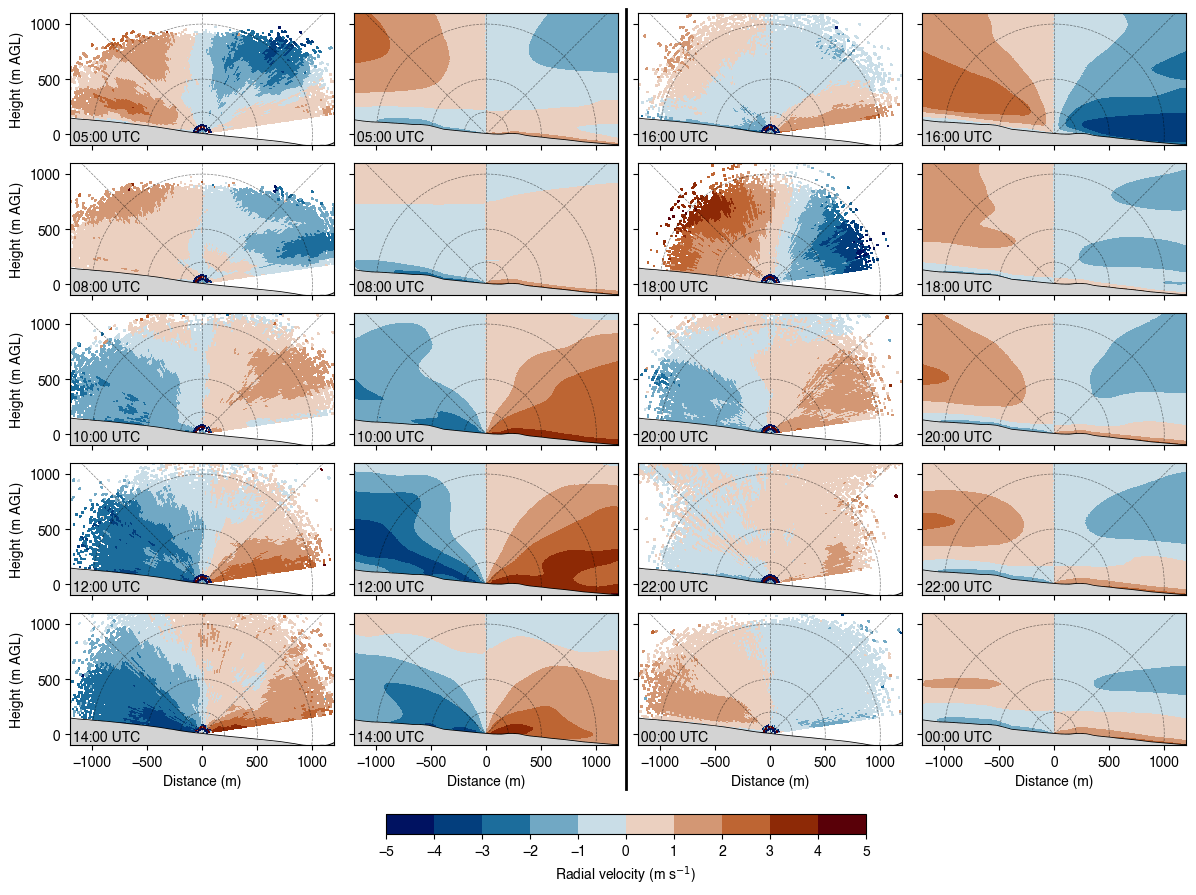

In [7]:
# discrete colormap
vmin, vmax = -5.0, 5.0 # boundary values for the rv colormap
rv_step = 1

bounds = np.arange(vmin, vmax+rv_step, rv_step)
cmap = plt.get_cmap(cm.vik)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)


fig, axes = plt.subplots(5, 4, figsize=(12,10), sharex=True, sharey=True, #gridspec_kw={'hspace': -0.4, 'wspace': 0.075}
                         )

row,col=0,0

for i, t in tqdm(enumerate(half_hours)):
    if i % 5 == 0 and i != 0:
        row = 0
        col += 2
    else:
        row = i % 5

    #--- 1. Prep work
    # get timestamps
    dt_rhi = pd.to_datetime(ds_rhi.half_hour.isel(half_hour=t).values)
    dt_icon = pd.to_datetime(ds_icon.time.isel(time=t).values)

    # get actual data (radial velocity
    dv_rhi  = ds_rhi.dv.isel(half_hour=t).values # open the RHI dataset at the respective index
    dv_rhi = np.fliplr(dv_rhi.T)

    dv_icon = ds_icon.rv.isel(time=t).values

    # Get the cartesian coordinates for both plots
    x_rhi = ds_rhi.x.isel(half_hour=t).values
    z_rhi = ds_rhi.z.isel(half_hour=t).values

    # trim RHI data to valid range (remove NaN values at the edges)
    valid = np.isfinite(x_rhi) & np.isfinite(z_rhi)

    vr = np.where(valid.any(axis=1))[0]
    vc = np.where(valid.any(axis=0))[0]

    x_rhi = x_rhi[vr.min():vr.max() + 1, vc.min():vc.max() + 1]
    z_rhi = z_rhi[vr.min():vr.max() + 1, vc.min():vc.max() + 1]
    dv_rhi = dv_rhi[vr.min():vr.max() + 1, vc.min():vc.max() + 1]


    #--- 2. RHI plot
    ax = axes[row, col]
    pcm25 = ax.pcolormesh(z_rhi, x_rhi, dv_rhi, shading="nearest", cmap=cmap, norm=norm)
    add_dt_text(ax, dt_rhi)
    add_dem(ax, dem_rhi)

    #--- 3. ICON plot
    #icon = np.ma.masked_invalid(dv_icon)
    ax = axes[row, col+1]
    ax.imshow(dv_icon, origin="lower", aspect="auto", interpolation="none", cmap=cmap, norm=norm, extent=icon_extent)
    add_dt_text(ax, dt_icon)
    add_dem(ax, dem_icon)

# limits and grid
for i,ax in enumerate(axes.flat):
    ax.set_xlim(-1200, 1200)
    ax.set_ylim(-100, zlim)
    ax.set_aspect("equal")
    add_range_semicircles_and_gridlines(ax, radii=[200, 500, 1000], zorder=8,
                                        lw=.5, ls='--', color='black', alpha = 0.5)
    for s in ax.spines.values(): s.set_zorder(50)   # subplot frame on top of DEM overlay
    if i % 4 == 0: ax.set_ylabel('Height (m AGL)')  # y labels for left column
    if i >= 16: ax.set_xlabel('Distance (m)')

# colorbar
cax = fig.add_axes([0.313, 0.12, 0.4, 0.02])
fig.colorbar(pcm25, cax=cax, orientation="horizontal",
             boundaries=bounds, ticks=bounds,
             label=r"Radial velocity (m s$^{-1}$)")

# add vertical separator between 2nd and 3rd column
sep = Line2D([0.513, 0.513], [0.165, .945], transform=fig.transFigure, color='k', linewidth=2)
fig.add_artist(sep)

# final formatting
fig.subplots_adjust(left=0.05, right=0.98, top=1,
                    bottom=0.15, wspace=0.075, hspace=-0.4)
plt.savefig(fig_png_dir + f'HEF_RHI_ICON_{rhi_angle}deg_{dt_from.strftime('%Y%m%d')}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_RHI_ICON_{rhi_angle}deg_{dt_from.strftime('%Y%m%d')}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()